# Feature Engineering
from those four files (sessions, users, flights and hotels), I want to create a new file - one row per user with data that may be useable for clustering

In [1]:
#Import
import pandas as pd
from platformdirs import user_state_dir

In [2]:
#loading data
sessions = pd.read_csv('preprocessed_data/sessions_preprocessed.csv')
users = pd.read_csv('preprocessed_data/users_preprocessed.csv')
hotels = pd.read_csv('preprocessed_data/hotels_preprocessed.csv')
flights = pd.read_csv('preprocessed_data/flights_preprocessed.csv')

In [3]:
#because when trips get cancelled, we have double/dublicated entries for the trip:
#here is a sessions table with only the cancelled ones (to eventually rule out later)
invalid_trip_ids = sessions[sessions["cancellation"]]["trip_id"]

# Users
since a lot of rows can be just taken from this table, I'll start with this one.

In [4]:
users.head()

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,Age,days_in
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,54,1619
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,53,1609
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17,45,1609
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24,47,1602
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10,54,1588


In [5]:
#we already have age and days in.

In [6]:
user_features = users.copy() #table to save all the features in, that may be interesting

In [7]:
#age buckets:
def age_group(age):
    if age < 35:
        return "18-35"
    elif age <= 50:
        return "35-50"
    elif age <= 65:
        return "50-65"
    else:
        return "65+"

In [8]:
user_features["Age Group"] = user_features["Age"].apply(age_group)

In [9]:
#at the end I will look over the table and decide which columns to delete.

# Sessions

### how many sessions per trip (before the booking, since the last booking)

In [10]:
sessions['user_id'].value_counts()

user_id
106907    14
252835    14
175032    14
118043    13
101486    13
          ..
551615     8
555075     8
564364     8
575208     8
583955     8
Name: count, Length: 5782, dtype: int64

In [11]:
# test with only one user
sessions_dummy =  sessions[:100][sessions["user_id"] == 217114].copy()

C:\Users\k-kah\AppData\Local\Temp\ipykernel_5140\3316556355.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sessions_dummy =  sessions[:100][sessions["user_id"] == 217114].copy()


In [12]:
#sort sessions for start date
sessions_dummy.sort_values("session_start", inplace=True)

In [13]:
#backward fill -> all sessions between bookings will get the trip id from the next booked trip
sessions_dummy["trip_id"] = sessions_dummy["trip_id"].bfill()

In [14]:
# stupidly, with this cancellations seem like bookings. So we need to delete the cancellation sessions

invalid_id = sessions_dummy[sessions_dummy["cancellation"]]["trip_id"]
sessions_dummy_valid = sessions_dummy[~sessions_dummy["trip_id"].isin(invalid_id)]
#aand the average number of session that dummy user needed to book a trip
sessions_dummy_valid.groupby("trip_id")["trip_id"].count().mean()

nan

In [15]:
#all together for every user:

def session_trip_rate(sessions_dummy):
    sessions_dummy.sort_values("session_start", inplace=True)
    sessions_dummy["trip_id"] = sessions_dummy["trip_id"].bfill()
    invalid_id = sessions_dummy[sessions_dummy["cancellation"]]["trip_id"]
    sessions_dummy_valid = sessions_dummy[~sessions_dummy["trip_id"].isin(invalid_id)]
    return sessions_dummy_valid.groupby("trip_id")["trip_id"].count().mean()

In [16]:
sesssion_trip_rate_feature = sessions.groupby("user_id").apply(session_trip_rate)  #  Feature

In [17]:
user_features['trip_session_ratio'] = user_features['user_id'].map(sesssion_trip_rate_feature)

### how many cancellations

<Axes: >

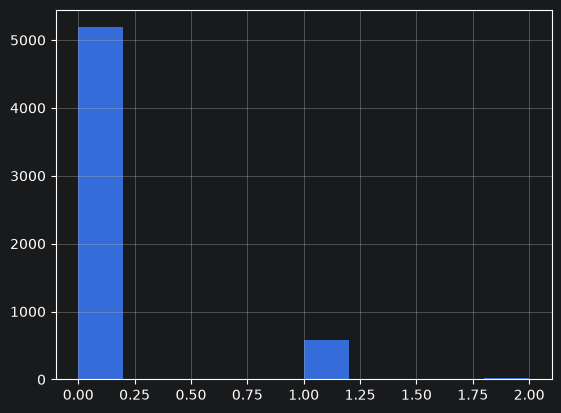

In [18]:
sessions.groupby('user_id')['cancellation'].sum().hist()

In [19]:
amount_cancellation = sessions.groupby('user_id')['cancellation'].sum()

user_features['no_cancellations'] = user_features['user_id'].map(amount_cancellation)

In [20]:
sessions.head()

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,648852-87415b144daa4f4d93a5cef1cf5dc582,648852,NaN,2023-03-17 17:22:00,2023-03-17 17:23:15,0.2,0.1,False,False,10,False
1,651269-61ce23b822c04a6e86d13ba33826dd3e,651269,651269-e9461ea9d60946549e665aa5ab818f1d,2023-03-17 21:32:00,2023-03-17 21:35:15,NaN,NaN,True,True,27,False
2,651613-5be2f8b2dd5a4dbcb6cd4ff0247fff2b,651613,651613-1acf724812d44470947dcab57872dd0f,2023-03-17 11:50:00,2023-03-17 11:53:27,NaN,NaN,True,True,28,False
3,653228-a6cf39a1619a42199f05ee8d33b9547b,653228,NaN,2023-03-17 14:14:00,2023-03-17 14:15:50,NaN,NaN,False,False,15,False
4,653281-6ec2b5f4c5fe48288e7c8e51ef78f6ce,653281,NaN,2023-03-17 14:57:00,2023-03-17 14:57:40,NaN,NaN,False,False,5,False


### how many page clicks

In [21]:
# sum
sum_page_clicks = sessions.groupby('user_id')['page_clicks'].sum()
#average
ave_page_clicks = sessions.groupby('user_id')['page_clicks'].mean()

In [22]:
user_features['sum_page_clicks'] = user_features['user_id'].map(sum_page_clicks)
user_features['ave_page_clicks'] = user_features['user_id'].map(ave_page_clicks)

### average discounts

In [24]:
mask = sessions['trip_id'].notna() #only the ones, where the users booked a trip invalid_trip_ids
mask = mask[~mask.isin(invalid_trip_ids)]
sessions.loc[mask, 'discount'] = sessions.loc[mask, ['flight_discount_amount','hotel_discount_amount']].mean(axis=1) #mean
ave_discount = sessions.groupby('user_id')['discount'].mean().sort_values().fillna(0)

In [27]:
user_features['ave_discount'] = user_features['user_id'].map(ave_discount)

# Hotels

In [28]:
# I need the user Id too
hotels_w_users = hotels.merge(sessions[["trip_id", "user_id"]], on="trip_id", how="left")

In [29]:
invalid_trip_ids = sessions[sessions["cancellation"]]["trip_id"] #again for all users
valid_hotels_w_users = hotels_w_users[~hotels_w_users["trip_id"].isin(invalid_trip_ids)]

### median nights per user

In [30]:
nights_median_feature = valid_hotels_w_users.groupby("user_id")["nights_new"].median() # Feature
nights_median_feature.name = "nights_median"

In [31]:
user_features['nights_median'] = user_features['user_id'].map(nights_median_feature)

### Charged cost per night

In [32]:
valid_hotels_w_users.head()

,trip_id,hotel_name,rooms,check_in_time,check_out_time,hotel_per_room_usd,checkin_weekday,checkout_weekday,nights_new,user_id
0,228872-47e5bd5e323748bb85e3a0944e6b6ad3,Banyan Tree - phoenix,1,2022-07-19 10:45:34.065,2022-07-23 11:00:00,107,1,5,4.0,228872
1,440212-96a28edb355f4656b9c3ce40dc380339,Radisson - baltimore,2,2022-12-05 09:34:32.700,2022-12-06 11:00:00,115,0,1,1.0,440212
2,446933-4273e6639af84810a800fa552fc8bdfd,Fairmont - new york,1,2022-12-14 11:00:00.000,2022-12-20 11:00:00,167,2,1,6.0,446933
3,478760-840b3de1be6748bebe15747d340b556d,Banyan Tree - hamilton,2,2022-12-22 11:00:00.000,2022-12-27 11:00:00,174,3,1,5.0,478760
4,443652-134aa9d023a54f63854c7e455754ba16,Shangri-La - austin,3,2022-12-30 13:33:33.345,2023-01-02 11:00:00,336,4,0,3.0,443652


In [33]:
hotels_valid_w_discount = valid_hotels_w_users.merge(sessions[["trip_id", "hotel_discount_amount"]], on="trip_id", how="left") #join tables
hotels_valid_w_discount["hotel_discount_amount"] = hotels_valid_w_discount["hotel_discount_amount"].fillna(0) #fill every discount with 0, because:
hotels_valid_w_discount["charged_fare"] = hotels_valid_w_discount["hotel_per_room_usd"]*hotels_valid_w_discount["rooms"]*hotels_valid_w_discount["nights_new"]*(1-hotels_valid_w_discount["hotel_discount_amount"])

In [34]:
hotels_sum_cost = hotels_valid_w_discount.groupby("user_id")["charged_fare"].sum() # Feature
#hotels_sum_cost.name = "hotel_tot_rev" #per user
hotels_avg_cost = hotels_valid_w_discount.groupby("user_id")["charged_fare"].mean() # Feature
#hotels_avg_cost.name = "hotel_avg_rev" #per user

In [35]:
user_features['hotel_tot_rev'] = user_features['user_id'].map(hotels_sum_cost)
user_features['hotel_avg_rev'] = user_features['user_id'].map(hotels_avg_cost)

### amount of booked hotel-trips

In [36]:
amount_hotel_bookings_feature = hotels_valid_w_discount[["trip_id", "user_id"]].groupby("user_id")["trip_id"].count()  # Features
#amount_hotel_bookings_feature.name = "hotels_no_bookings"

In [37]:
user_features['hotels_no_bookings'] = user_features['user_id'].map(amount_hotel_bookings_feature)

### how many nights spent every user

In [38]:
total_nights_spent_feature = hotels_valid_w_discount.groupby("user_id")["nights_new"].sum()  # Feature
#total_nights_spent_feature.name = "hotel_tot_nights"
average_nights_spent_feature = hotels_valid_w_discount.groupby("user_id")["nights_new"].mean()  # Feature
#average_nights_spent_feature.name = "hotel_avg_nights"

In [39]:
user_features['hotel_tot_nights'] = user_features['user_id'].map(total_nights_spent_feature)
user_features['hotel_avg_nights'] = user_features['user_id'].map(average_nights_spent_feature)

### favourite hotel destination

In [41]:
valid_hotels_w_users.head()

,trip_id,hotel_name,rooms,check_in_time,check_out_time,hotel_per_room_usd,checkin_weekday,checkout_weekday,nights_new,user_id
0,228872-47e5bd5e323748bb85e3a0944e6b6ad3,Banyan Tree - phoenix,1,2022-07-19 10:45:34.065,2022-07-23 11:00:00,107,1,5,4.0,228872
1,440212-96a28edb355f4656b9c3ce40dc380339,Radisson - baltimore,2,2022-12-05 09:34:32.700,2022-12-06 11:00:00,115,0,1,1.0,440212
2,446933-4273e6639af84810a800fa552fc8bdfd,Fairmont - new york,1,2022-12-14 11:00:00.000,2022-12-20 11:00:00,167,2,1,6.0,446933
3,478760-840b3de1be6748bebe15747d340b556d,Banyan Tree - hamilton,2,2022-12-22 11:00:00.000,2022-12-27 11:00:00,174,3,1,5.0,478760
4,443652-134aa9d023a54f63854c7e455754ba16,Shangri-La - austin,3,2022-12-30 13:33:33.345,2023-01-02 11:00:00,336,4,0,3.0,443652


In [42]:
#new columns for the hotel and the city
valid_hotels_w_users['hotel'] = valid_hotels_w_users['hotel_name'].str.split(' - ').str[0].str.strip()

In [43]:
valid_hotels_w_users['city_destination'] = valid_hotels_w_users['hotel_name'].str.split(' - ').str[1].str.strip()
valid_hotels_w_users.head()

,trip_id,hotel_name,rooms,check_in_time,check_out_time,hotel_per_room_usd,checkin_weekday,checkout_weekday,nights_new,user_id,hotel,city_destination
0,228872-47e5bd5e323748bb85e3a0944e6b6ad3,Banyan Tree - phoenix,1,2022-07-19 10:45:34.065,2022-07-23 11:00:00,107,1,5,4.0,228872,Banyan Tree,phoenix
1,440212-96a28edb355f4656b9c3ce40dc380339,Radisson - baltimore,2,2022-12-05 09:34:32.700,2022-12-06 11:00:00,115,0,1,1.0,440212,Radisson,baltimore
2,446933-4273e6639af84810a800fa552fc8bdfd,Fairmont - new york,1,2022-12-14 11:00:00.000,2022-12-20 11:00:00,167,2,1,6.0,446933,Fairmont,new york
3,478760-840b3de1be6748bebe15747d340b556d,Banyan Tree - hamilton,2,2022-12-22 11:00:00.000,2022-12-27 11:00:00,174,3,1,5.0,478760,Banyan Tree,hamilton
4,443652-134aa9d023a54f63854c7e455754ba16,Shangri-La - austin,3,2022-12-30 13:33:33.345,2023-01-02 11:00:00,336,4,0,3.0,443652,Shangri-La,austin


array([[<Axes: title={'center': 'count'}>]], dtype=object)

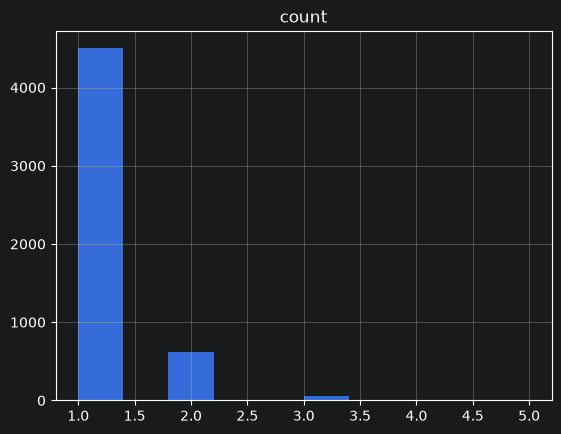

In [44]:
valid_hotels_w_users.groupby('user_id')['city_destination'].agg(
    most_common=lambda x: x.mode()[0],
    count=lambda x: x.value_counts().iloc[0]
).hist()
#they mostly don't have a favourite destination

array([[<Axes: title={'center': 'count'}>]], dtype=object)

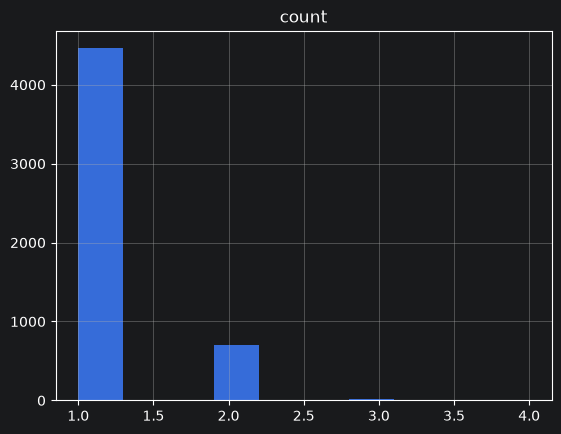

In [45]:
valid_hotels_w_users.groupby('user_id')['hotel'].agg(
    most_common=lambda x: x.mode()[0],
    count=lambda x: x.value_counts().iloc[0]
).hist()
#also no favourite hotel... so here no new columns for user features

### average cost per night per room
better to differentiate between people who spend a lot and families

In [46]:
#avg cost per seat -> maybe there are some discount hunters
hotels_valid_w_discount["charged_per_r_n"] = hotels_valid_w_discount["hotel_per_room_usd"] * (
            1 - hotels_valid_w_discount["hotel_discount_amount"])
hotel_avg_cost_per_r_n = hotels_valid_w_discount.groupby("user_id")["charged_per_r_n"].mean()  # Feature
user_features['hotel_avg_cost_per_r_n'] = user_features['user_id'].map(hotel_avg_cost_per_r_n)

# Flights

In [47]:
flights_w_users = flights.merge(sessions[["trip_id", "user_id"]], on="trip_id", how="left")
flights_valid = flights_w_users[~flights_w_users["trip_id"].isin(invalid_trip_ids)]

### how many flights booked every user

In [48]:
amount_flights_feature = flights_valid[["trip_id", "seats", "user_id"]].groupby("user_id")["trip_id"].count()  # Features
#amount_flights_feature.name = "flight_no_bookings"

flights_w_users = flights.merge(sessions[["trip_id", "user_id"]], on="trip_id", how="left")

In [49]:
user_features['flight_no_bookings'] = user_features['user_id'].map(amount_flights_feature)

In [50]:
user_features.head()

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,...,ave_page_clicks,ave_discount,nights_median,hotel_tot_rev,hotel_avg_rev,hotels_no_bookings,hotel_tot_nights,hotel_avg_nights,hotel_avg_cost_per_r_n,flight_no_bookings
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,...,8.333333,0.000000,1.0,230.00,115.000000,2.0,2.0,1.000000,90.000000,3.0
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,...,26.153846,0.091936,4.0,2640.00,880.000000,3.0,11.0,3.666667,163.666667,2.0
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,...,18.166667,0.100000,4.0,3520.00,502.857143,7.0,26.0,3.714286,150.285714,6.0
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,...,26.285714,0.162905,6.0,2185.20,1092.600000,2.0,12.0,6.000000,182.600000,1.0
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,...,16.153846,0.137702,6.5,6443.45,1610.862500,4.0,24.0,6.000000,218.850000,3.0


### average seats

In [51]:
seats_average_feature = flights_valid[["trip_id", "seats", "user_id"]].groupby("user_id")["seats"].mean() # Feature
#seats_average_feature.name = "flight_avg_seats"

In [52]:
user_features['flight_avg_seats'] = user_features['user_id'].map(seats_average_feature)

### ave & sum total flight costs

In [53]:
flights_valid_w_discount = flights_valid.merge(sessions[["trip_id", "flight_discount_amount"]], on="trip_id", how="left")

In [54]:
flights_valid_w_discount["flight_discount_amount"] = flights_valid_w_discount["flight_discount_amount"].fillna(0)

flights_valid_w_discount["charged_fare"] = flights_valid_w_discount["base_fare_usd"]*flights_valid_w_discount["seats"]*(1-flights_valid_w_discount["flight_discount_amount"])

In [55]:
flight_avg_cost = flights_valid_w_discount.groupby("user_id")["charged_fare"].mean() # Feature
flight_avg_cost.name = "flight_avg_rev"

flight_sum_cost = flights_valid_w_discount.groupby("user_id")["charged_fare"].sum() # Feature
flight_sum_cost.name = "flight_tot_rev"

In [56]:
user_features['flight_avg_rev'] = user_features['user_id'].map(flight_avg_cost)
user_features['flight_tot_rev'] = user_features['user_id'].map(flight_sum_cost)

In [57]:
#avg cost per seat -> maybe there are some discount hunters
flights_valid_w_discount["charged_per_seat"] = flights_valid_w_discount["base_fare_usd"]*(1-flights_valid_w_discount["flight_discount_amount"])
flight_avg_cost_per_seat = flights_valid_w_discount.groupby("user_id")["charged_per_seat"].mean() # Feature

In [58]:
user_features['flight_avg_cost_per_seat'] = user_features['user_id'].map(flight_avg_cost_per_seat)

### favourite destination

In [59]:
#flights_valid.groupby('user_id')['destination'].agg(lambda x: x.mode()[0])
#first entry is enough for me, although it might change the data a little bit (cities that are higher in the alphabet are more likely to appear here. Same for hotels

array([[<Axes: title={'center': 'count'}>]], dtype=object)

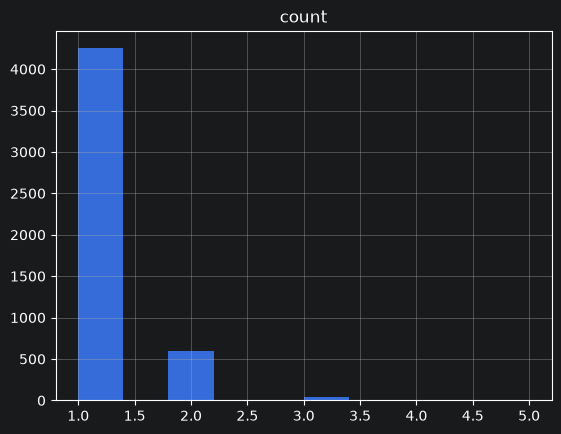

In [60]:
flights_valid.groupby('user_id')['destination'].agg(
    most_common=lambda x: x.mode()[0],
    count=lambda x: x.value_counts().iloc[0]
).hist()

In [61]:
# also mostly one-timers..
#fave_flight_dest = flights_valid.groupby('user_id')['destination'].agg(lambda x: x.mode()[0])
#user_features['fave_flight_dest'] = user_features['user_id'].map(fave_flight_dest)

fave airline

In [62]:
flights_valid.head()

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id
0,526901-0bb64144805e44419bd60af3f9bc4bb1,DAL,edmonton,YXD,1,True,2023-07-30 07:00:00,2023-08-02 07:00:00,0,Delta Air Lines,53.667,-113.467,476.00,526901
1,635790-71504937f58f41158486c9ff024bfafe,BOS,portland,PDX,1,True,2023-07-29 11:00:00,2023-08-02 11:00:00,1,Delta Air Lines,45.589,-122.597,736.52,635790
2,379543-786b5bc990ab42348075f170807f4625,SJC,tucson,TUS,1,True,2022-11-04 13:00:00,2022-11-07 13:00:00,1,JetBlue Airways,32.166,-110.883,207.16,379543
3,408551-35b342c868fa4dcfae23554edc29491e,UGN,new york,JFK,2,True,2022-11-20 12:00:00,2022-11-24 12:00:00,0,Uzbekistan Airways,40.640,-73.779,427.94,408551
4,417679-624d84164bc443e6bfc876d4a84d358c,LGA,louisville,LOU,3,True,2022-11-26 07:00:00,2022-11-29 07:00:00,0,American Airlines,38.228,-85.664,547.45,417679


In [63]:
flights_valid.groupby('user_id')['trip_airline'].agg(
    most_common=lambda x: x.mode()[0],
    count=lambda x: x.value_counts().iloc[0]
).sort_values(by=['count'], ascending=False)

,most_common,count
user_id,,
608629,United Airlines,4
586887,American Airlines,4
517549,Delta Air Lines,4
506427,American Airlines,4
526471,Southwest Airlines,4
...,...,...
742639,Ryanair,1
745292,Delta Air Lines,1
751545,Avianca - Aerovias Nacionales de Colombia,1


array([[<Axes: title={'center': 'count'}>]], dtype=object)

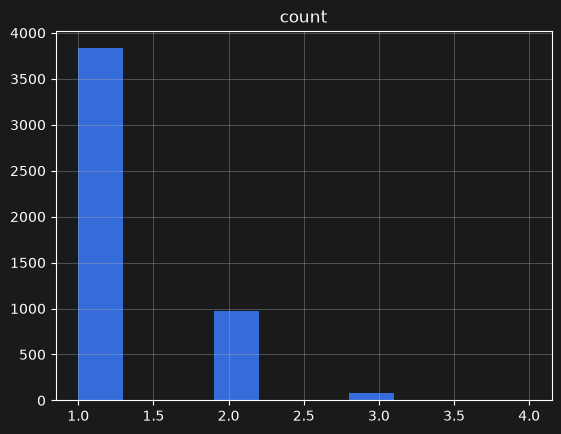

In [64]:
flights_valid.groupby('user_id')['trip_airline'].agg(
    most_common=lambda x: x.mode()[0],
    count=lambda x: x.value_counts().iloc[0]
).hist()
# nearly all entries are 1 or 2 timers, so the airline is also not really significant

In [67]:
user_features['ave_rev_per_day'] = (user_features['hotel_tot_rev']+user_features['flight_tot_rev'])/user_features['days_in']

# Export user features

In [68]:
user_features.columns

Index(['user_id', 'birthdate', 'gender', 'married', 'has_children',
       'home_country', 'home_city', 'home_airport', 'home_airport_lat',
       'home_airport_lon', 'sign_up_date', 'Age', 'days_in', 'Age Group',
       'trip_session_ratio', 'no_cancellations', 'sum_page_clicks',
       'ave_page_clicks', 'ave_discount', 'nights_median', 'hotel_tot_rev',
       'hotel_avg_rev', 'hotels_no_bookings', 'hotel_tot_nights',
       'hotel_avg_nights', 'hotel_avg_cost_per_r_n', 'flight_no_bookings',
       'flight_avg_seats', 'flight_avg_rev', 'flight_tot_rev',
       'flight_avg_cost_per_seat', 'ave_rev_per_day'],
      dtype='str')

In [69]:
#exporting to clean and overview in the next notebook
user_features.to_csv('user_features_data/user_features.csv', index=False)